In [15]:
#1
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
#2
!pip install torch torchvision scikit-learn seaborn tqdm -q

In [17]:
#3
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [18]:
#4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

!nvidia-smi

Using Device: cuda
Fri May 22 06:17:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------------

In [19]:
#5
base_path = "/content/drive/MyDrive/Data"

train_fire_path = os.path.join(base_path, "Train_Data", "Fire")

train_non_fire_path = os.path.join(base_path, "Train_Data", "Non_Fire")

test_fire_path = os.path.join(base_path, "Test_Data", "Fire")

test_non_fire_path = os.path.join(base_path, "Test_Data", "Non_Fire")

In [35]:
#6
train_fire = random.sample(os.listdir(train_fire_path), 300)

train_non_fire = random.sample(os.listdir(train_non_fire_path), 300)

test_fire = random.sample(os.listdir(test_fire_path), 70)

test_non_fire = random.sample(os.listdir(test_non_fire_path), 70)

ValueError: Sample larger than population or is negative

In [36]:
#7
train_paths = []
train_labels = []

test_paths = []
test_labels = []

# FIRE = 1
# NON_FIRE = 0

for img in train_fire:

    train_paths.append(os.path.join(train_fire_path, img))
    train_labels.append(1)

for img in train_non_fire:

    train_paths.append(os.path.join(train_non_fire_path, img))
    train_labels.append(0)

for img in test_fire:

    test_paths.append(os.path.join(test_fire_path, img))
    test_labels.append(1)

for img in test_non_fire:

    test_paths.append(os.path.join(test_non_fire_path, img))
    test_labels.append(0)

print("Train Images:", len(train_paths))
print("Test Images:", len(test_paths))

Train Images: 600
Test Images: 20


In [37]:
#8
transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [38]:
#9
class FireDataset(Dataset):

    def __init__(self, image_paths, labels, transform=None):

        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        image_path = self.image_paths[idx]

        try:
            image = Image.open(image_path).convert("RGB")

        except:
            image = Image.new("RGB", (224, 224))

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]

        return image, label

In [39]:
#10
train_dataset = FireDataset(
    train_paths,
    train_labels,
    transform
)

test_dataset = FireDataset(
    test_paths,
    test_labels,
    transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [40]:
#11
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze early layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

print("ResNet50 Ready!")

ResNet50 Ready!


In [41]:
#12
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

EPOCHS = 20

In [42]:
#13
train_losses = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {epoch_loss:.4f}")

100%|██████████| 19/19 [01:33<00:00,  4.91s/it]


Epoch [1/20] Loss: 0.4750


100%|██████████| 19/19 [00:04<00:00,  3.89it/s]


Epoch [2/20] Loss: 0.2595


100%|██████████| 19/19 [00:05<00:00,  3.62it/s]


...

Epoch [18/20] Loss: 0.0469


100%|██████████| 19/19 [00:05<00:00,  3.24it/s]


Epoch [19/20] Loss: 0.0463


100%|██████████| 19/19 [00:04<00:00,  4.16it/s]

Epoch [20/20] Loss: 0.0391


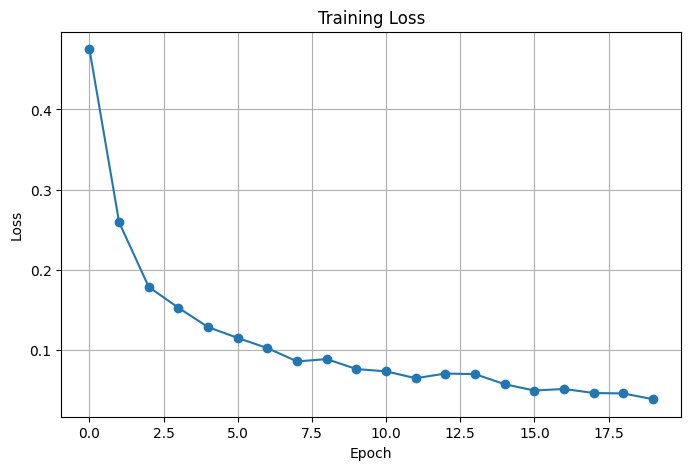

In [43]:
#14
plt.figure(figsize=(8,5))

plt.plot(train_losses, marker='o')

plt.title("Training Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid()

plt.show()

In [44]:
#15
model.eval()

all_predictions = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total

print(f"\nTest Accuracy: {accuracy:.2f}%")


Test Accuracy: 85.00%


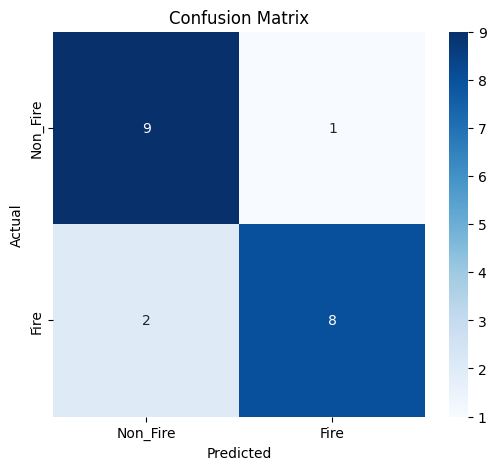

In [45]:
#16
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Non_Fire", "Fire"],
    yticklabels=["Non_Fire", "Fire"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [46]:
#17
print(classification_report(
    all_labels,
    all_predictions,
    target_names=["Non_Fire", "Fire"]
))

              precision    recall  f1-score   support

    Non_Fire       0.82      0.90      0.86        10
        Fire       0.89      0.80      0.84        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20



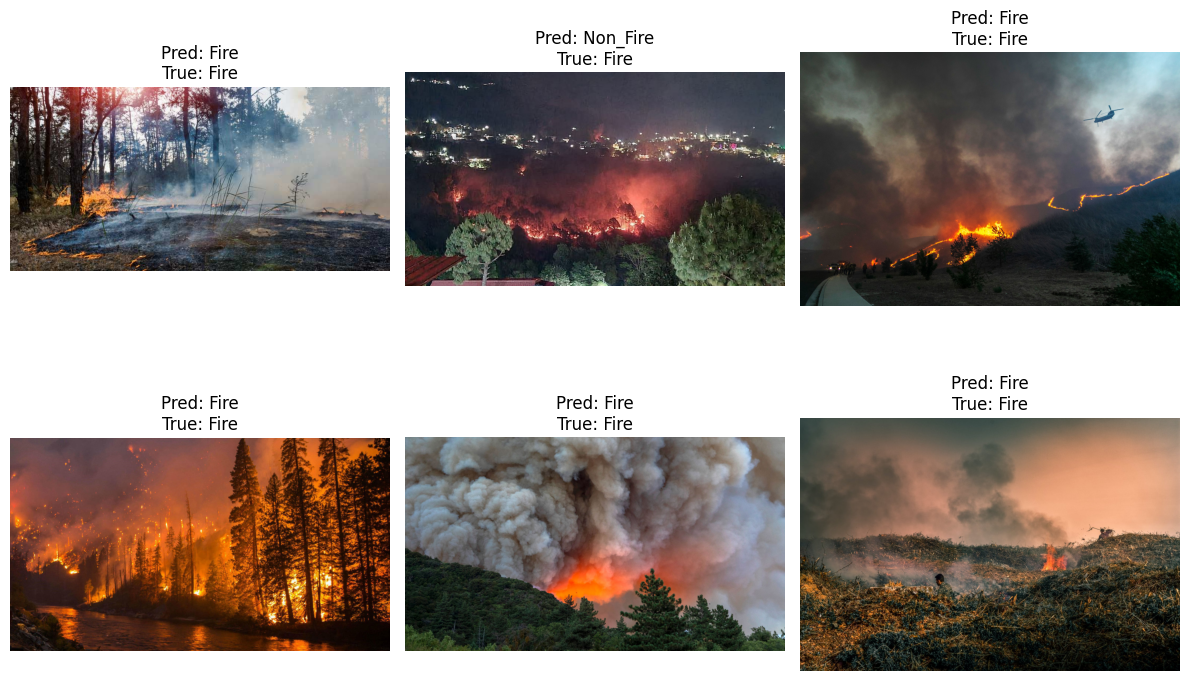

In [47]:
#18
class_names = ["Non_Fire", "Fire"]

plt.figure(figsize=(12,8))

for i in range(6):

    image = Image.open(test_paths[i]).convert("RGB")

    plt.subplot(2,3,i+1)

    plt.imshow(image)

    plt.axis("off")

    pred = class_names[all_predictions[i]]

    true = class_names[all_labels[i]]

    plt.title(f"Pred: {pred}\nTrue: {true}")

plt.tight_layout()

plt.show()